Device: cuda
Mode:   FULL
Shape: (551065, 5)
                                           seriesuid  coordX  coordY  coordZ  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -56.08  -67.85 -311.92   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...   53.21 -244.41 -245.17   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.66 -121.80 -286.62   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -33.66  -72.75 -308.41   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -32.25  -85.36 -362.51   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  

Class distribution:
class
0    549714
1      1351
Name: count, dtype: int64

Negative:Positive ratio ~ 407:1


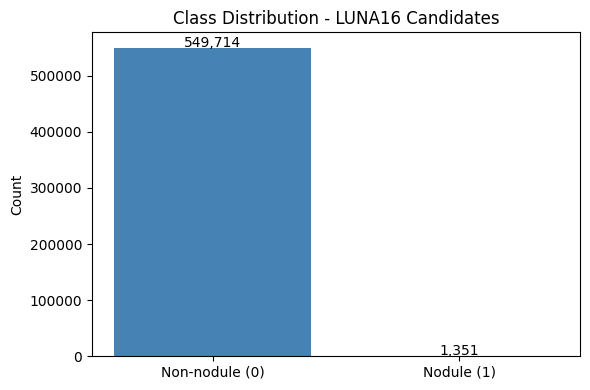

CT volumes found: 445
Candidates after filtering: 275,358

class       0    1
split             
test    54362  147
train  165568  433
val     54707  141
  train: 20/267 series done
  train: 40/267 series done
  train: 60/267 series done
  train: 80/267 series done
  train: 100/267 series done
  train: 120/267 series done
  train: 140/267 series done
  train: 160/267 series done
  train: 180/267 series done
  train: 200/267 series done
  train: 220/267 series done
  train: 240/267 series done
  train: 260/267 series done
train done - shape: (4652, 3, 64, 64) | positives: 416 | skipped: 111
  val: 20/89 series done
  val: 40/89 series done
  val: 60/89 series done
  val: 80/89 series done
val done - shape: (1481, 3, 64, 64) | positives: 128 | skipped: 70
  test: 20/89 series done
  test: 40/89 series done
  test: 60/89 series done
  test: 80/89 series done
test done - shape: (3048, 3, 64, 64) | positives: 144 | skipped: 39

Extraction complete.
Train - positives: 416 | negatives: 4236 |

100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s] 


[sampler_plus_posweight] pos_weight = 10.18 (computed from raw train ratio)
[sampler_plus_posweight] Epoch 01/20 | Train Loss: 1.3636 | Val AUC: 0.7967 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 02/20 | Train Loss: 0.9341 | Val AUC: 0.8899 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 03/20 | Train Loss: 0.5618 | Val AUC: 0.9188 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 04/20 | Train Loss: 0.4157 | Val AUC: 0.9454 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 05/20 | Train Loss: 0.3528 | Val AUC: 0.9495 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 06/20 | Train Loss: 0.2920 | Val AUC: 0.9477 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 07/20 | Train Loss: 0.2501 | Val AUC: 0.9506 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 08/20 | Train Loss: 0.2136 | Val AUC: 0.9538 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 09/20 | Train Loss: 0.1664 | Val AUC: 0.9685 | LR: 1.00e-04
[sampler_plus_posweight] Epoch 10/20 | Train Loss: 0.1151 | Val AUC: 0.9640 | LR: 1.00e-04
[sampler_plus_

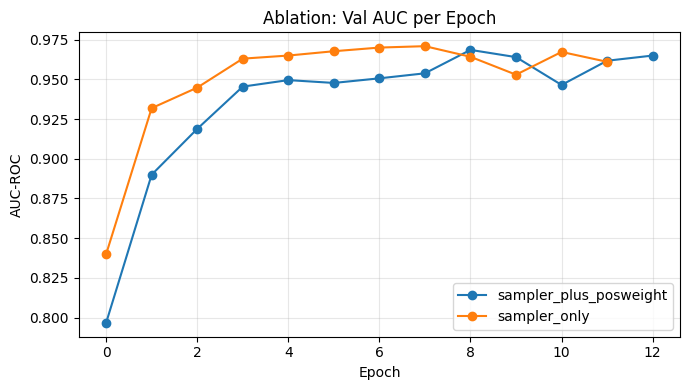


SELECTED CONFIG: sampler_only  (AUC CIs overlap; picked higher specificity at matched 90% sensitivity)
Operating threshold (selected on validation): 0.0826
Test AUC-ROC: 0.9633  (bootstrap 95% CI: [0.9446, 0.9789], n=1000)

Applied threshold (from validation): 0.0826
Sensitivity: 0.8750
Specificity: 0.9428
Precision:   0.4315  (low precision is expected/acceptable here - 
             the threshold is deliberately set to prioritise sensitivity
             for a screening task, at the cost of more false positives)

Confusion matrix:
  TN=2738  FP= 166
  FN=  18  TP= 126
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.6 MB/s eta 0:00:00
TP:4  TN:4  FP:4  FN:4


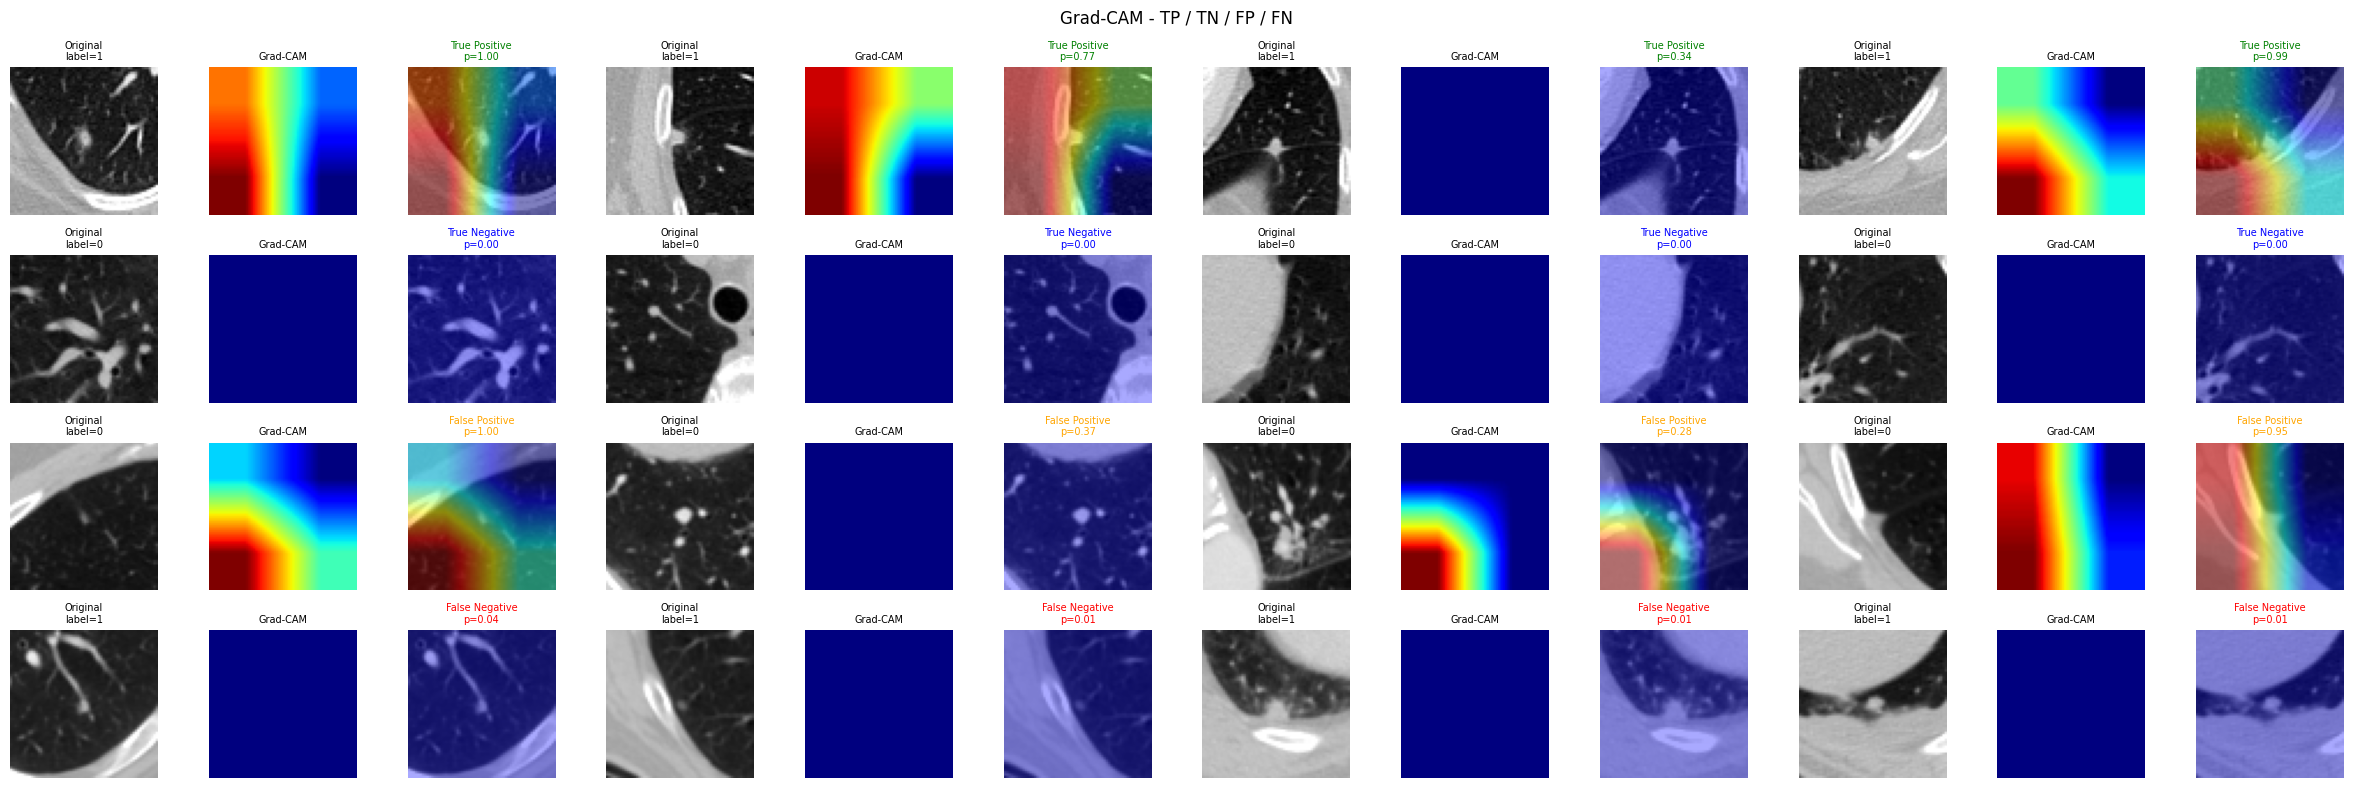


Run complete. Report back: ablation table, selected config, test AUC + CI,
confusion matrix, and any errors/warnings - then we'll fix the 888/889 count
and write the README together.


In [2]:
"""
LUNA16 Lung Nodule Classifier — v2
Binary classification of lung nodule candidates from CT scans.

CHANGES FROM v1 (per methodology review before presenting to PhD supervisors):

1. [REFRAME] Train/val/test is a single split by LUNA16 subset (0-2 / 3 / 4),
   not the official 10-fold cross-validation protocol. This is now stated
   explicitly as a compute/time scope decision, not implied as equivalent to
   the standard protocol. Results are NOT compared to CV-averaged literature
   numbers (see docstring in Section 5).

2. [DOCUMENT] 2.5D input (3 adjacent axial slices as pseudo-RGB channels)
   is used instead of a full 3D CNN. This is a deliberate scope decision,
   documented with reasoning in Section 6, not an oversight.

3. [ABLATION] The original script combined WeightedRandomSampler (oversamples
   positives in each batch) with pos_weight in the loss (further reweights by
   the ORIGINAL 10:1 ratio, even though the sampler already changes what the
   network actually sees to ~4:1). Stacking both without checking whether they
   over-correct was a real gap. This version runs both configs as an explicit
   ablation, compares them on validation, and states a decision rule for which
   one goes forward to test. See Section 9-10.

4. [RIGOR FIX] The 90%-sensitivity operating threshold was previously chosen
   directly on the TEST set — i.e., the "final" numbers were partly tuned on
   the data being reported on. Threshold is now selected on the VALIDATION set
   only, then applied fixed to test. See Section 11.

5. [RIGOR] Test AUC is now reported with a bootstrap 95% CI instead of a bare
   point estimate, given the small number of test positives (n=144).

6. [REPRODUCIBILITY] Global random seeds are now set (numpy, python random,
   torch, cuda) - previously only pandas sampling had a fixed seed, so full
   training runs were not exactly reproducible.

Still TODO after running (per plan): fix the 888 vs 889 CT scan count in the
README, clean up notebook output noise, write the README with the reframed
limitations. That happens after this script is run and results are back.
"""

# ============================================================
# 1. Imports
# ============================================================
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import subprocess
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms

# ============================================================
# 2. Configuration
# ============================================================
MINI_RUN = False   # True = quick pipeline test | False = full run

BASE_DIR   = Path("/kaggle/input/datasets/avc0706/luna16")
SUBSETS    = [BASE_DIR / f"subset{i}" / f"subset{i}" for i in range(5)]
CANDIDATES = BASE_DIR / "candidates.csv"
PATCH_DIR  = Path("/kaggle/working/patches")
PATCH_DIR.mkdir(exist_ok=True)

PATCH_SIZE = 64
HU_MIN     = -1000
HU_MAX     = 400

NEG_RATIO = {"train": 10, "val": 10, "test": 20}
POS_CAP   = {"train": 50, "val": 15, "test": 15} if MINI_RUN else {"train": 9999, "val": 9999, "test": 9999}

BATCH_SIZE     = 32 if MINI_RUN else 64
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4

N_BOOTSTRAP = 1000   # bootstrap resamples for AUC confidence intervals
SEED        = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI' if MINI_RUN else 'FULL'}")

# ============================================================
# 3. Reproducibility  [NEW]
# ============================================================
# v1 only fixed the seed for pandas sampling (random_state=42 in .sample()).
# Training itself (weight init, batch order, dropout if any, CUDA nondeterminism)
# was not seeded, so re-running the notebook could give a different AUC each
# time. This doesn't change results, it just makes them reproducible so a
# reviewer (or you, in six months) can rerun and get the same number.
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed(SEED)

# ============================================================
# 4. Data Exploration
# ============================================================
df = pd.read_csv(CANDIDATES)
print(f"Shape: {df.shape}")
print(df.head())
print(f"\nClass distribution:\n{df['class'].value_counts()}")
print(f"\nNegative:Positive ratio ~ {df['class'].value_counts()[0] / df['class'].value_counts()[1]:.0f}:1")

counts = df["class"].value_counts().sort_index()
plt.figure(figsize=(6, 4))
bars = plt.bar(["Non-nodule (0)", "Nodule (1)"], counts.values, color=["steelblue", "tomato"])
plt.title("Class Distribution - LUNA16 Candidates")
plt.ylabel("Count")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

# ============================================================
# 5. File Mapping and Splits
# ============================================================
# SCOPE DECISION - SINGLE SPLIT VS 10-FOLD CV [REFRAME]
# --------------------------------------------------------------
# LUNA16's official protocol (per the challenge site) is 10-fold
# cross-validation: train on 9 subsets, test on the 10th, rotate, average.
# This project instead uses a single fixed split (subsets 0-2 train / 3 val /
# 4 test) on 5 of the 10 subsets.
#
# Why: full 10-fold CV means 10x the preprocessing + training time, which
# doesn't fit the scope of a portfolio project meant to demonstrate
# methodology rather than compete on the leaderboard. This is a deliberate
# time/compute trade-off, not an oversight.
#
# Consequence, stated plainly: a single split on ~144 test positives gives
# a noisier AUC estimate than a 10-fold average would, and it is NOT directly
# comparable to papers that report FROC/CPM averaged over 10-fold CV on the
# full dataset. This project reports its own AUC as an internal metric and
# does not claim it is comparable to leaderboard numbers.
# --------------------------------------------------------------
def build_uid_to_path(subset_dirs):
    uid_to_path = {}
    for subset_dir in subset_dirs:
        for mhd_file in Path(subset_dir).glob("*.mhd"):
            uid_to_path[mhd_file.stem] = mhd_file
    return uid_to_path

uid_to_path = build_uid_to_path(SUBSETS)
print(f"CT volumes found: {len(uid_to_path)}")

def get_subset_number(uid):
    path = uid_to_path.get(uid)
    if path is None:
        return None
    return int(path.parent.name.replace("subset", ""))

def assign_split(subset_num):
    if subset_num in [0, 1, 2]:
        return "train"
    elif subset_num == 3:
        return "val"
    else:
        return "test"

df["subset"] = df["seriesuid"].apply(get_subset_number)
df_filtered  = df.dropna(subset=["subset"]).copy()
df_filtered["subset"]   = df_filtered["subset"].astype(int)
df_filtered["split"]    = df_filtered["subset"].apply(assign_split)
df_filtered["mhd_path"] = df_filtered["seriesuid"].apply(lambda uid: str(uid_to_path[uid]))

print(f"Candidates after filtering: {len(df_filtered):,}")
print()
print(df_filtered.groupby(["split", "class"]).size().unstack(fill_value=0))

# ============================================================
# 6. Patch Extraction
# ============================================================
# SCOPE DECISION - 2.5D (3 SLICES) VS FULL 3D CNN [DOCUMENT]
# --------------------------------------------------------------
# Nodules are 3D structures, and a true 3D CNN (as used in DeepLung, 3DFPN,
# and most top LUNA16 leaderboard entries) can use volumetric shape to help
# separate real nodules from vessel/airway cross-sections that look similar
# in a single 2D slice. This project instead extracts 3 adjacent axial slices
# (z-1, z, z+1) and treats them as pseudo-RGB channels for a 2D ResNet-18 -
# a common "2.5D" simplification, but a real information loss relative to
# full 3D context.
#
# Why: it lets a standard ImageNet-pretrained 2D backbone be reused directly,
# and keeps training time and volumetric memory usage far lower than 3D
# convolutions - appropriate for portfolio scope, not because 3D is
# unimportant. The Grad-CAM false-positive analysis later (vessels/airways
# misread as nodules) is a direct, visible consequence of this choice.
# --------------------------------------------------------------
def resample_volume(sitk_image):
    original_spacing = sitk_image.GetSpacing()
    original_size    = sitk_image.GetSize()
    new_spacing      = [1.0, 1.0, 1.0]
    new_size = [
        int(round(original_size[i] * original_spacing[i] / new_spacing[i]))
        for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)
    return resampler.Execute(sitk_image)

def world_to_voxel(world_coord, origin, spacing):
    return np.round((np.array(world_coord) - origin) / spacing).astype(int)

def extract_patch(volume, voxel_coord):
    x, y, z = voxel_coord
    half     = PATCH_SIZE // 2
    z_dim, y_dim, x_dim = volume.shape

    if (z - 1 < 0 or z + 1 >= z_dim or
            y - half < 0 or y + half > y_dim or
            x - half < 0 or x + half > x_dim):
        return None

    channels = [
        volume[z + dz, y - half : y + half, x - half : x + half]
        for dz in [-1, 0, 1]
    ]
    patch = np.stack(channels, axis=0).astype(np.float32)
    patch = np.clip(patch, HU_MIN, HU_MAX)
    patch = (patch - HU_MIN) / (HU_MAX - HU_MIN)
    return patch

def extract_split(df_split, split_name):
    all_pos   = df_split[df_split["class"] == 1]
    positives = all_pos.sample(n=min(POS_CAP[split_name], len(all_pos)), random_state=SEED)
    all_neg   = df_split[df_split["class"] == 0]
    n_neg     = min(len(all_neg), len(positives) * NEG_RATIO[split_name])
    negatives = all_neg.sample(n=n_neg, random_state=SEED)

    df_use  = pd.concat([positives, negatives]).reset_index(drop=True)
    grouped = df_use.groupby("seriesuid")

    all_patches, all_labels, skipped = [], [], 0

    for i, (uid, group) in enumerate(grouped):
        sitk_img = sitk.ReadImage(group["mhd_path"].iloc[0])
        sitk_img = resample_volume(sitk_img)
        origin   = np.array(sitk_img.GetOrigin())
        spacing  = np.array(sitk_img.GetSpacing())
        volume   = sitk.GetArrayFromImage(sitk_img)

        for _, row in group.iterrows():
            world = np.array([row["coordX"], row["coordY"], row["coordZ"]])
            voxel = world_to_voxel(world, origin, spacing)
            patch = extract_patch(volume, voxel)
            if patch is None:
                skipped += 1
                continue
            all_patches.append(patch)
            all_labels.append(int(row["class"]))

        if (i + 1) % 20 == 0:
            print(f"  {split_name}: {i + 1}/{len(grouped)} series done")

    patches_arr = np.stack(all_patches)
    labels_arr  = np.array(all_labels)
    np.save(PATCH_DIR / f"patches_{split_name}.npy", patches_arr)
    np.save(PATCH_DIR / f"labels_{split_name}.npy",  labels_arr)
    print(f"{split_name} done - shape: {patches_arr.shape} | positives: {labels_arr.sum()} | skipped: {skipped}")

for split_name in ["train", "val", "test"]:
    extract_split(df_filtered[df_filtered["split"] == split_name], split_name)

print("\nExtraction complete.")

# ============================================================
# 7. Dataset and DataLoaders
# ============================================================
class NoduleDataset(Dataset):
    def __init__(self, patches_path, labels_path, transform=None):
        self.patches   = np.load(patches_path)
        self.labels    = np.load(labels_path).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = torch.from_numpy(self.patches[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            patch = self.transform(patch)
        return patch, label

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

train_ds = NoduleDataset(PATCH_DIR / "patches_train.npy", PATCH_DIR / "labels_train.npy", transform=train_transform)
val_ds   = NoduleDataset(PATCH_DIR / "patches_val.npy",   PATCH_DIR / "labels_val.npy")
test_ds  = NoduleDataset(PATCH_DIR / "patches_test.npy",  PATCH_DIR / "labels_test.npy")

train_labels = train_ds.labels
n_pos        = int(train_labels.sum())
n_neg        = len(train_labels) - n_pos
print(f"Train - positives: {n_pos} | negatives: {n_neg} | ratio: {n_neg/n_pos:.1f}:1")

sample_weights = np.where(train_labels == 1, 1.0 / n_pos, 4.0 / n_neg)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

patches_b, labels_b = next(iter(train_loader))
print(f"Batch shape:     {patches_b.shape}")
print(f"Batch pos count: {labels_b.sum().int().item()} / {len(labels_b)}")
print("Note: sampler targets ~1 positive per 4 negatives per batch - this is the")
print("effective ratio the network trains on, NOT the original 10:1 ratio.")

# ============================================================
# 8. Model Training Function  [REFACTORED for ablation]
# ============================================================
def train_one_config(config_name, use_pos_weight, train_loader, val_loader,
                      n_pos, n_neg, device, max_epochs=MAX_EPOCHS,
                      patience=EARLY_PATIENCE, lr=1e-4, seed=SEED):
    """
    Trains one ResNet-18 config and returns its history plus the best
    validation predictions (for later ablation comparison and bootstrap CI).
    use_pos_weight=True reproduces the v1 setup (sampler + pos_weight stacked).
    use_pos_weight=False isolates the sampler alone.
    """
    set_global_seed(seed)  # same init/order for both configs -> fair comparison

    model = models.resnet18(weights="IMAGENET1K_V1")
    model.fc = nn.Linear(512, 1)
    model = model.to(device)

    if use_pos_weight:
        pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
        print(f"[{config_name}] pos_weight = {pos_weight.item():.2f} (computed from raw train ratio)")
    else:
        criterion = nn.BCEWithLogitsLoss()
        print(f"[{config_name}] no pos_weight - sampler is the only imbalance mechanism")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

    best_auc, patience_count = 0.0, 0
    history = {"train_loss": [], "val_auc": []}
    best_val_probs, best_val_targets = None, None
    ckpt_path = f"/kaggle/working/best_model_{config_name}.pth"

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_loss = 0.0
        for patches, labels in train_loader:
            patches = patches.to(device)
            labels  = labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(patches), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(labels)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_probs, val_targets = [], []
        with torch.no_grad():
            for patches, labels in val_loader:
                probs = torch.sigmoid(model(patches.to(device))).squeeze(1).cpu().numpy()
                val_probs.extend(probs)
                val_targets.extend(labels.numpy())

        val_auc = roc_auc_score(val_targets, val_probs)
        scheduler.step(val_auc)
        history["train_loss"].append(train_loss)
        history["val_auc"].append(val_auc)
        print(f"[{config_name}] Epoch {epoch:02d}/{max_epochs} | Train Loss: {train_loss:.4f} | "
              f"Val AUC: {val_auc:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

        if val_auc > best_auc:
            best_auc, patience_count = val_auc, 0
            torch.save(model.state_dict(), ckpt_path)
            best_val_probs, best_val_targets = np.array(val_probs), np.array(val_targets)
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"[{config_name}] Early stopping at epoch {epoch}.")
                break

    print(f"[{config_name}] Best Val AUC: {best_auc:.4f}\n")
    return {
        "config_name": config_name,
        "history": history,
        "best_val_auc": best_auc,
        "best_val_probs": best_val_probs,
        "best_val_targets": best_val_targets,
        "ckpt_path": ckpt_path,
    }

# ============================================================
# 9. Ablation: sampler-only vs sampler+pos_weight  [NEW]
# ============================================================
def bootstrap_auc_ci(y_true, y_probs, n_bootstraps=N_BOOTSTRAP, seed=SEED, alpha=0.05):
    """Bootstrap 95% CI for AUC-ROC. Skips resamples missing a class."""
    rng = np.random.RandomState(seed)
    y_true  = np.asarray(y_true)
    y_probs = np.asarray(y_probs)
    n = len(y_true)
    scores = []
    for _ in range(n_bootstraps):
        idx = rng.randint(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        scores.append(roc_auc_score(y_true[idx], y_probs[idx]))
    scores = np.sort(np.array(scores))
    lower = scores[int((alpha / 2) * len(scores))]
    upper = scores[int((1 - alpha / 2) * len(scores))]
    return float(np.mean(scores)), float(lower), float(upper)

def threshold_at_sensitivity(y_true, y_probs, target=0.90):
    """Returns (sensitivity, specificity, threshold) for the first ROC point
    meeting the target sensitivity. Falls back to closest point if none reach it."""
    fpr, tpr, thresholds = roc_curve(y_true, y_probs)
    valid = [(tpr[i], 1 - fpr[i], thresholds[i]) for i in range(len(tpr)) if tpr[i] >= target]
    if valid:
        return valid[0]
    idx = np.argmin(np.abs(tpr - target))
    return tpr[idx], 1 - fpr[idx], thresholds[idx]

print("=" * 70)
print("ABLATION: does stacking pos_weight on top of the sampler help or hurt?")
print("=" * 70)

ablation_results = {}
for use_pw, name in [(True, "sampler_plus_posweight"), (False, "sampler_only")]:
    ablation_results[name] = train_one_config(
        name, use_pw, train_loader, val_loader, n_pos, n_neg, DEVICE
    )

print("Ablation comparison (validation set):")
print(f"{'Config':<26}{'Val AUC':<10}{'95% CI':<20}{'Sens':<8}{'Spec (@90% sens)'}")
summary = {}
for name, res in ablation_results.items():
    mean_auc, lo, hi = bootstrap_auc_ci(res["best_val_targets"], res["best_val_probs"])
    sens, spec, thr = threshold_at_sensitivity(res["best_val_targets"], res["best_val_probs"], 0.90)
    summary[name] = {"mean_auc": mean_auc, "ci": (lo, hi), "sens": sens, "spec": spec, "thr": thr}
    print(f"{name:<26}{res['best_val_auc']:<10.4f}[{lo:.4f}, {hi:.4f}]   {sens:<8.4f}{spec:.4f}")

# comparison plot
fig, ax = plt.subplots(figsize=(7, 4))
for name, res in ablation_results.items():
    ax.plot(res["history"]["val_auc"], marker="o", label=name)
ax.set_title("Ablation: Val AUC per Epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC-ROC")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 10. Model Selection  [NEW - explicit, stated decision rule]
# ============================================================
# Decision rule, stated up front rather than picked after seeing results:
#  1. If the bootstrap CIs on val AUC do NOT overlap, pick the higher-AUC config.
#  2. If they DO overlap (difference not distinguishable from noise given only
#     ~128 val positives), pick on specificity at the matched 90%-sensitivity
#     operating point, since that's the clinically relevant number for a
#     screening task.
#  3. If that's also indistinguishable, prefer the SIMPLER config
#     (sampler_only) - fewer interacting mechanisms is easier to defend and
#     easier to reason about if it fails later.
names = list(summary.keys())
a, b = summary[names[0]], summary[names[1]]
ci_overlap = not (a["ci"][1] < b["ci"][0] or b["ci"][1] < a["ci"][0])

if not ci_overlap:
    selected = names[0] if a["mean_auc"] > b["mean_auc"] else names[1]
    reason = "non-overlapping AUC CIs, picked higher AUC"
elif abs(a["spec"] - b["spec"]) > 0.02:  # >2 pts specificity difference treated as meaningful
    selected = names[0] if a["spec"] > b["spec"] else names[1]
    reason = "AUC CIs overlap; picked higher specificity at matched 90% sensitivity"
else:
    selected = "sampler_only"
    reason = "AUC and specificity both indistinguishable; defaulting to simpler config"

print(f"\nSELECTED CONFIG: {selected}  ({reason})")
final_ckpt = ablation_results[selected]["ckpt_path"]

# ============================================================
# 11. Threshold Selection on VALIDATION, applied fixed to TEST  [RIGOR FIX]
# ============================================================
# v1 selected the 90%-sensitivity threshold directly from the test ROC curve.
# That means the reported confusion matrix was tuned to hit exactly 90%
# sensitivity ON the data being reported on - a soft form of test leakage.
# The threshold is now taken from validation and simply applied to test.
final_threshold = summary[selected]["thr"]
print(f"Operating threshold (selected on validation): {final_threshold:.4f}")

# ============================================================
# 12. Test Evaluation with Bootstrap CI
# ============================================================
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 1)
model.load_state_dict(torch.load(final_ckpt))
model = model.to(DEVICE)
model.eval()

test_probs, test_targets = [], []
with torch.no_grad():
    for patches, labels in test_loader:
        probs = torch.sigmoid(model(patches.to(DEVICE))).squeeze(1).cpu().numpy()
        test_probs.extend(probs)
        test_targets.extend(labels.numpy())

test_probs   = np.array(test_probs)
test_targets = np.array(test_targets)

test_auc = roc_auc_score(test_targets, test_probs)
mean_auc, ci_lo, ci_hi = bootstrap_auc_ci(test_targets, test_probs)
print(f"Test AUC-ROC: {test_auc:.4f}  (bootstrap 95% CI: [{ci_lo:.4f}, {ci_hi:.4f}], n={N_BOOTSTRAP})")

preds = (test_probs >= final_threshold).astype(int)
cm = confusion_matrix(test_targets, preds)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision   = tp / (tp + fp) if (tp + fp) > 0 else float("nan")

print(f"\nApplied threshold (from validation): {final_threshold:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision:   {precision:.4f}  (low precision is expected/acceptable here - ")
print(f"             the threshold is deliberately set to prioritise sensitivity")
print(f"             for a screening task, at the cost of more false positives)")
print(f"\nConfusion matrix:")
print(f"  TN={tn:4d}  FP={fp:4d}")
print(f"  FN={fn:4d}  TP={tp:4d}")

# ============================================================
# 13. Grad-CAM
# ============================================================
subprocess.run(["pip", "install", "grad-cam", "-q"])
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

results = list(zip(test_targets, test_probs, range(len(test_targets))))
tp_ex = [(t, p, i) for t, p, i in results if t == 1 and p >= final_threshold][:4]
tn_ex = [(t, p, i) for t, p, i in results if t == 0 and p <  final_threshold][:4]
fp_ex = [(t, p, i) for t, p, i in results if t == 0 and p >= final_threshold][:4]
fn_ex = [(t, p, i) for t, p, i in results if t == 1 and p <  final_threshold][:4]

print(f"TP:{len(tp_ex)}  TN:{len(tn_ex)}  FP:{len(fp_ex)}  FN:{len(fn_ex)}")

categories = [("True Positive",  tp_ex, "green"),
              ("True Negative",  tn_ex, "blue"),
              ("False Positive", fp_ex, "orange"),
              ("False Negative", fn_ex, "red")]

fig, axes = plt.subplots(4, 12, figsize=(24, 8))

for row_idx, (cat_name, samples, color) in enumerate(categories):
    for col_offset, (true_label, prob, idx) in enumerate(samples):
        patch   = torch.from_numpy(test_ds.patches[idx]).unsqueeze(0).to(DEVICE)
        heatmap = cam(input_tensor=patch)[0]
        centre  = test_ds.patches[idx][1]
        rgb     = np.stack([centre] * 3, axis=-1)
        overlay = show_cam_on_image(rgb, heatmap, use_rgb=True)
        c = col_offset * 3

        axes[row_idx, c].imshow(centre, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, c].set_title(f"Original\nlabel={int(true_label)}", fontsize=7)
        axes[row_idx, c].axis("off")

        axes[row_idx, c+1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
        axes[row_idx, c+1].set_title("Grad-CAM", fontsize=7)
        axes[row_idx, c+1].axis("off")

        axes[row_idx, c+2].imshow(overlay)
        axes[row_idx, c+2].set_title(f"{cat_name}\np={prob:.2f}", fontsize=7, color=color)
        axes[row_idx, c+2].axis("off")

    for col_offset in range(len(samples), 4):
        for c in range(3):
            axes[row_idx, col_offset * 3 + c].axis("off")

plt.suptitle("Grad-CAM - TP / TN / FP / FN", fontsize=12)
plt.tight_layout()
plt.show()

print("\nRun complete. Report back: ablation table, selected config, test AUC + CI,")
print("confusion matrix, and any errors/warnings - then we'll fix the 888/889 count")
print("and write the README together.")